In [353]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [354]:
D = 1
x0 = 1
x_target = 0
dt = 1e-4
max_time = 100
n_trials = 100
xmin = 1
np.random.seed(42)

In [355]:
def mfpt_theory(lam):
    return (np.exp(x0*np.sqrt(lam/D)) - 1)/lam 

In [356]:
z_star = 1.59362426
lam_star = D*z_star**2/(x0**2)

In [357]:
def gen_fpts_exp(lam, n = n_trials, D = D, x0 = x0):
    fpts = np.zeros(n)

    for i in range(n):

        t = 0
        fpt_found = False
        while t < max_time:
            x=x0

            reset = np.random.exponential(1/lam)
            t_loc = 0
            while t_loc < reset:

                x += np.sqrt(2*D*dt)*np.random.normal()
                t_loc += dt
                t += dt

                if x <= x_target:
                    fpts[i] = t
                    fpt_found = True
                    break

                if t >= max_time:
                    break
            
            if fpt_found:
                break
        
       
    
    return fpts

def gen_fpts_pareto(alpha, n = n_trials, D = D, x0 = x0, xmin = xmin):
    fpts = np.zeros(n)

    for i in range(n):

        t = 0
        fpt_found = False
        while t < max_time:
            x=x0

            u = np.random.uniform()
            reset = xmin * (1 - u) ** (-1/alpha)
            reset = min(reset, max_time)
            t_loc = 0
            while t_loc < reset:

                x += np.sqrt(2*D*dt)*np.random.normal()
                t_loc += dt
                t += dt

                if x <= x_target:
                    fpts[i] = t
                    fpt_found = True
                    break

                if t >= max_time:
                    break
            
            if fpt_found:
                break
        
       
    
    return fpts

In [358]:
lambdas = np.linspace(1, 5, 20)
mfpt_sim = np.zeros(len(lambdas))
mfpt_err = np.zeros(len(lambdas))
mfpt_the = np.zeros(len(lambdas))

In [359]:
for idx, lam in tqdm(enumerate(lambdas), total = len(lambdas), desc = "lambda sweep"):
    fpts = gen_fpts_exp(lam)
    valid = fpts
    valid[valid == 0] = max_time
    n_timeouts = n_trials - len(valid)
    mfpt_sim[idx] = np.mean(valid)
    mfpt_err[idx] = np.std(valid)/np.sqrt(len(valid))
    mfpt_the[idx] = mfpt_theory(lam)
    print(f"λ={lam:.4f}  MFPT_sim={mfpt_sim[idx]:.3f}  MFPT_theory={mfpt_the[idx]:.3f}")

print(mfpt_err)


lambda sweep:   5%|▌         | 1/20 [00:04<01:28,  4.68s/it]

λ=1.0000  MFPT_sim=1.321  MFPT_theory=1.718


lambda sweep:  10%|█         | 2/20 [00:10<01:38,  5.45s/it]

λ=1.2105  MFPT_sim=1.781  MFPT_theory=1.656


lambda sweep:  15%|█▌        | 3/20 [00:16<01:35,  5.65s/it]

...

λ=2.4737  MFPT_sim=1.837  MFPT_theory=1.544


lambda sweep:  45%|████▌     | 9/20 [00:44<00:51,  4.71s/it]

λ=2.6842  MFPT_sim=1.321  MFPT_theory=1.545


lambda sweep:  45%|████▌     | 9/20 [00:44<00:54,  5.00s/it]


KeyboardInterrupt: 

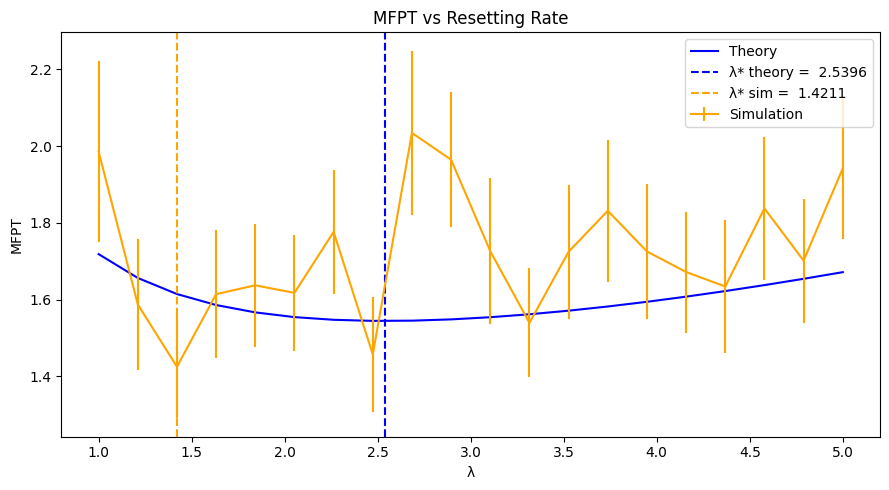

In [ ]:
lam_opt_sim = lambdas[np.argmin(mfpt_sim)]

plt.figure(figsize=(9, 5))
plt.plot(lambdas, mfpt_the, label = "Theory", color = "blue")
plt.errorbar(lambdas, mfpt_sim, yerr = mfpt_err, label = "Simulation", color = "orange")
plt.axvline(lam_star, color = "blue", linestyle = '--', label = f"λ* theory = {lam_star: .4f}")
plt.axvline(lam_opt_sim, color = "orange", linestyle = '--', label =f"λ* sim = {lam_opt_sim: .4f}")
plt.xlabel("λ")
plt.ylabel("MFPT")
plt.title("MFPT vs Resetting Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
fpts_test = gen_fpts_exp(lam_star, n=100, D=D, x0=x0)
valid = fpts_test[fpts_test > 0]
print(f"Timeout rate: {(100 - len(valid))/100 * 100:.1f}%")
print(f"MFPT: {np.mean(valid):.4f}  (theory: {mfpt_theory(lam_star):.4f})")

Timeout rate: 0.0%
MFPT: 1.8722  (theory: 1.5441)


Pareto sweep: 100%|██████████| 3/3 [00:04<00:00,  1.52s/it]


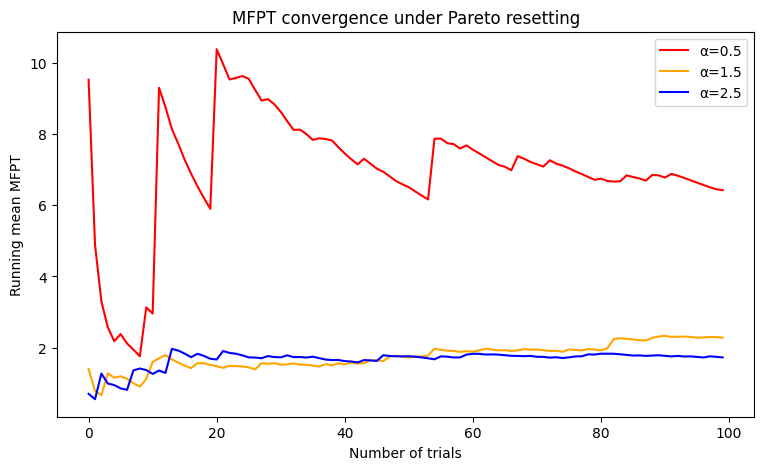

In [ ]:
alphas = [0.5, 1.5, 2.5]
colors = ["red", "orange", "blue"]
plt.figure(figsize=(9, 5))
for alpha, color in tqdm(zip(alphas, colors), total=len(alphas), desc="Pareto sweep"):
    fpts = gen_fpts_pareto(alpha)
    fpts[fpts == 0] = max_time
    means = [np.mean(fpts[:i]) for i in range(1, len(fpts)+1)]
    plt.plot(means, color=color, label=f"α={alpha}")
plt.xlabel("Number of trials")
plt.ylabel("Running mean MFPT")
plt.title("MFPT convergence under Pareto resetting")
plt.legend()
plt.show()